# TP4 — Recherche d’emploi féminin dans *Le Soir* en 1938 et 1939

Ce notebook étudie les passages liés à la recherche d’emploi féminin dans les pages du journal *Le Soir* publiées en 1938 et 1939.

Le corpus a été constitué dans CAMille avec la requête exacte `"jeune fille" AND "cherche place"`, puis limité au journal *Le Soir* et aux années 1938–1939. Cette recherche a produit 903 résultats : 496 pages pour 1938 et 407 pages pour 1939.

CAMille fournit des pages complètes de journaux et non des annonces déjà séparées. Une page peut donc contenir plusieurs annonces, mais aussi d’autres textes. L’analyse commencera par l’exploration des métadonnées et l’extraction des passages proches des expressions recherchées avant l’application des méthodes du cours.

## 1. Chargement et vérification des données

In [1]:
from pathlib import Path
import re

import pandas as pd
from collections import Counter
from nltk import word_tokenize
from nltk.corpus import stopwords

In [2]:
data_dir = Path("../../data/tp4_jeune_fille")
textes_dir = data_dir / "textes"

xlsx_files = list(data_dir.glob("*.xlsx"))

text_files = sorted(
    fichier for fichier in textes_dir.glob("*.txt")
    if fichier.name != "_README.txt"
)

print("Fichier XLSX trouvé :", len(xlsx_files))
print("Pages de journal trouvées :", len(text_files))

Fichier XLSX trouvé : 1
Pages de journal trouvées : 903


In [4]:
metadata_df = pd.read_excel(xlsx_files[0])

print("Nombre de résultats :", len(metadata_df))
print("Nombre de colonnes :", len(metadata_df.columns))
print("Colonnes disponibles :", metadata_df.columns.tolist())

metadata_df.head()

Nombre de résultats : 903
Nombre de colonnes : 11
Colonnes disponibles : ['ID', 'JOURNAL', 'DATE', 'ANNÉE', 'MOIS', 'JOUR', 'JDLS', 'ÉDITION', 'PAGE', 'LANGUE', 'TEXTE']


,ID,JOURNAL,DATE,ANNÉE,MOIS,JOUR,JDLS,ÉDITION,PAGE,LANGUE,TEXTE
0,KB_JB838_1938-07-20_01-00011,JB838,1938-07-20,1938,7,20,3,1,11,fr-BE,Rossel au n» 42375 J <kw>JEUNE FILLE</kw> stén...
1,KB_JB838_1938-01-10_01-00010,JB838,1938-01-10,1938,1,10,1,1,10,fr-BE,"WALLONNE très débr., poié, au cour, ganterie, ..."
2,KB_JB838_1938-01-28_01-00012,JB838,1938-01-28,1938,1,28,5,1,12,fr-BE,MERLANS “j brillants J [50 Stockviseli f détre...
3,KB_JB838_1938-02-23_01-00015,JB838,1938-02-23,1938,2,23,3,1,15,fr-BE,"<kw>Jeune fille</kw> ça- LE?SOIR 15 ble, parla..."
4,KB_JB838_1938-02-06_01-00016,JB838,1938-02-06,1938,2,6,7,1,16,fr-BE,Coupeur <kw>JEUNE FILLE</kw> pr aider manutent...


In [5]:
metadata_df["DATE"] = pd.to_datetime(metadata_df["DATE"])

print("Identifiants uniques :", metadata_df["ID"].nunique())
print("Identifiants dupliqués :", metadata_df["ID"].duplicated().sum())
print("Textes manquants :", metadata_df["TEXTE"].isna().sum())

resume_annees = (
    metadata_df
    .groupby("ANNÉE")
    .agg(
        nombre_pages=("ID", "nunique"),
        premiere_date=("DATE", "min"),
        derniere_date=("DATE", "max"),
        pages_distinctes=("PAGE", "nunique")
    )
    .reset_index()
)

resume_annees

Identifiants uniques : 903
Identifiants dupliqués : 0
Textes manquants : 0


,ANNÉE,nombre_pages,premiere_date,derniere_date,pages_distinctes
0,1938,496,1938-01-01,1938-12-31,12
1,1939,407,1939-01-01,1939-12-31,15


### Vérification du corpus

Le fichier contient 903 pages distinctes, sans identifiant dupliqué ni texte manquant. Les 496 pages de 1938 couvrent l’année du 1er janvier au 31 décembre, tandis que les 407 pages de 1939 couvrent également une année complète. Les résultats se répartissent sur 12 numéros de page distincts en 1938 et 15 en 1939.

Le volume n’est pas identique pour les deux années. Une comparaison fondée uniquement sur les nombres bruts donnerait donc davantage de poids à 1938. Les comparaisons entre les deux années devront aussi utiliser des proportions ou des fréquences relatives.

In [10]:
pages_par_numero = pd.crosstab(
    index=metadata_df["PAGE"],
    columns=metadata_df["ANNÉE"]
)

pages_par_numero["total"] = pages_par_numero.sum(axis=1)

pages_par_numero = (
    pages_par_numero
    .sort_values("total", ascending=False)
)

pages_par_numero


ANNÉE,1938,1939,total
PAGE,,,
12,99,69,168
11,85,73,158
13,88,48,136
14,72,31,103
10,48,34,82
9,12,47,59
15,33,12,45
8,0,39,39
16,24,12,36


In [11]:
pages_10_14 = metadata_df["PAGE"].between(10, 14).sum()
proportion_10_14 = pages_10_14 / len(metadata_df) * 100

print("Résultats situés entre les pages 10 et 14 :", pages_10_14)
print("Part du corpus :", round(proportion_10_14, 1), "%")


Résultats situés entre les pages 10 et 14 : 647
Part du corpus : 71.7 %


### Répartition par numéro de page

Les résultats sont principalement situés dans la seconde moitié du journal. Les pages 10 à 14 regroupent 647 des 903 résultats, soit 71,7 % du corpus. Les pages 11, 12 et 13 sont les plus représentées.

Cette concentration correspond aux extraits observés, qui contiennent de nombreuses rubriques d’offres et de demandes d’emploi. Le numéro de page ne permet toutefois pas d’identifier automatiquement une annonce : la pagination varie entre 1938 et 1939 et une même page peut contenir plusieurs rubriques. L’analyse portera donc sur les passages textuels associés à la requête, et non sur le numéro de page seul.

In [12]:
nombre_par_mois = pd.crosstab(
    index=metadata_df["MOIS"],
    columns=metadata_df["ANNÉE"]
)

pourcentage_par_mois = (
    nombre_par_mois
    .div(nombre_par_mois.sum(axis=0), axis=1)
    .mul(100)
    .round(1)
)

repartition_mensuelle = pd.DataFrame({
    "1938_nombre": nombre_par_mois[1938],
    "1938_pourcentage": pourcentage_par_mois[1938],
    "1939_nombre": nombre_par_mois[1939],
    "1939_pourcentage": pourcentage_par_mois[1939]
})

repartition_mensuelle

,1938_nombre,1938_pourcentage,1939_nombre,1939_pourcentage
MOIS,,,,
1,46,9.3,34,8.4
2,41,8.3,35,8.6
3,49,9.9,47,11.5
4,49,9.9,37,9.1
5,49,9.9,32,7.9
6,37,7.5,38,9.3
7,42,8.5,34,8.4
8,44,8.9,25,6.1
9,35,7.1,41,10.1


### Répartition mensuelle

Les résultats sont présents pendant les douze mois des deux années. Aucun mois ne représente plus de 11,5 % des pages d’une année. Le corpus n’est donc pas limité à une période courte ou à un événement ponctuel. La diminution visible en novembre et décembre 1939 devra être décrite avec prudence, car le nombre de pages dépend aussi du fonctionnement de la recherche, de la composition du journal et de la qualité de l’OCR.

## 2. Repérage des expressions et extraction des passages

In [13]:
def nettoyer_texte(texte):
    texte = re.sub(r"</?kw>", "", texte, flags=re.IGNORECASE)
    texte = re.sub(r"\s+", " ", texte)
    return texte.strip()


metadata_df["texte_nettoye"] = metadata_df["TEXTE"].apply(nettoyer_texte)

metadata_df["nb_jeune_fille"] = (
    metadata_df["texte_nettoye"]
    .str.lower()
    .str.count("jeune fille")
)

metadata_df["nb_cherche_place"] = (
    metadata_df["texte_nettoye"]
    .str.lower()
    .str.count("cherche place")
)

print(
    "Pages contenant « jeune fille » :",
    (metadata_df["nb_jeune_fille"] > 0).sum()
)
print(
    "Pages contenant « cherche place » :",
    (metadata_df["nb_cherche_place"] > 0).sum()
)
print(
    "Occurrences de « jeune fille » :",
    metadata_df["nb_jeune_fille"].sum()
)
print(
    "Occurrences de « cherche place » :",
    metadata_df["nb_cherche_place"].sum()
)

Pages contenant « jeune fille » : 878
Pages contenant « cherche place » : 891
Occurrences de « jeune fille » : 2188
Occurrences de « cherche place » : 3266


In [14]:
def extraire_termes_surlignes(texte):
    return re.findall(
        r"<kw>(.*?)</kw>",
        texte,
        flags=re.IGNORECASE | re.DOTALL
    )


metadata_df["termes_surlignes"] = (
    metadata_df["TEXTE"]
    .apply(extraire_termes_surlignes)
)

pages_avec_les_deux = (
    (metadata_df["nb_jeune_fille"] > 0)
    & (metadata_df["nb_cherche_place"] > 0)
)

print("Pages contenant les deux expressions exactes :", pages_avec_les_deux.sum())
print("Pages ne contenant pas « jeune fille » exactement :", (metadata_df["nb_jeune_fille"] == 0).sum())
print("Pages ne contenant pas « cherche place » exactement :", (metadata_df["nb_cherche_place"] == 0).sum())

metadata_df.loc[
    ~pages_avec_les_deux,
    ["ID", "ANNÉE", "termes_surlignes"]
].head(10)

Pages contenant les deux expressions exactes : 866
Pages ne contenant pas « jeune fille » exactement : 25
Pages ne contenant pas « cherche place » exactement : 12


,ID,ANNÉE,termes_surlignes
171,KB_JB838_1939-05-11_01-00012,1939,"[cherche place, cherche place, cherche place, ..."
173,KB_JB838_1939-03-08_01-00013,1939,"[cherche place, cherche place, cherche place, ..."
315,KB_JB838_1938-10-19_01-00012,1938,"[cherche place, cherche place, cherche place, ..."
386,KB_JB838_1939-04-06_01-00013,1939,"[cherche place, cherche place, jeune “ fille, ..."
389,KB_JB838_1938-04-10_01-00018,1938,"[cherche place, cherche place, cherche -place,..."
414,KB_JB838_1938-08-17_01-00009,1938,"[jeune fille, jeune' fille, jeune* fille, Jeun..."
415,KB_JB838_1938-11-07_01-00012,1938,"[cherche place, cherche place, cherche place, ..."
474,KB_JB838_1939-02-21_01-00012,1939,"[cherche place, cherche place, cherche place, ..."
497,KB_JB838_1939-06-21_01-00013,1939,"[cherche place, cherche place, cherche place, ..."
500,KB_JB838_1938-06-30_01-00013,1938,"[jeune' fille, JEUNE. FILLE, cherche place, ch..."


In [15]:
termes_surlignes_df = (
    metadata_df[["ID", "ANNÉE", "termes_surlignes"]]
    .explode("termes_surlignes")
    .dropna(subset=["termes_surlignes"])
)

termes_surlignes_df["forme"] = (
    termes_surlignes_df["termes_surlignes"]
    .str.lower()
    .str.strip()
)

frequence_formes = (
    termes_surlignes_df["forme"]
    .value_counts()
    .head(30)
    .rename_axis("forme_surlignee")
    .reset_index(name="frequence")
)

frequence_formes

,forme_surlignee,frequence
0,cherche place,3257
1,jeune fille,2185
2,jeune - fille,21
3,jeune-fille,7
4,cherche' place,6
5,"jeune, fille",5
6,cherche -place,5
7,cherche .place,4
8,cherche - place,4
9,cherche ' place,4


In [16]:
def normaliser_expressions(texte):
    texte = re.sub(
        r"\bjeune\W+fille\b",
        "jeune fille",
        texte,
        flags=re.IGNORECASE
    )
    texte = re.sub(
        r"\bcherche\W+place\b",
        "cherche place",
        texte,
        flags=re.IGNORECASE
    )
    return texte


metadata_df["texte_normalise"] = (
    metadata_df["texte_nettoye"]
    .apply(normaliser_expressions)
)

metadata_df["nb_jeune_fille_normalise"] = (
    metadata_df["texte_normalise"]
    .str.lower()
    .str.count("jeune fille")
)

metadata_df["nb_cherche_place_normalise"] = (
    metadata_df["texte_normalise"]
    .str.lower()
    .str.count("cherche place")
)

pages_avec_les_deux_normalisees = (
    (metadata_df["nb_jeune_fille_normalise"] > 0)
    & (metadata_df["nb_cherche_place_normalise"] > 0)
)

print(
    "Pages contenant les deux expressions après normalisation :",
    pages_avec_les_deux_normalisees.sum()
)
print(
    "Pages restant sans les deux expressions :",
    (~pages_avec_les_deux_normalisees).sum()
)

Pages contenant les deux expressions après normalisation : 893
Pages restant sans les deux expressions : 10


In [ ]:
pages_a_verifier = metadata_df.loc[
    ~pages_avec_les_deux_normalisees,
    ["ID", "ANNÉE", "termes_surlignes"]
]

for _, ligne in pages_a_verifier.iterrows():
    print("ID :", ligne["ID"])
    print("Année :", ligne["ANNÉE"])
    print("Termes surlignés :", ligne["termes_surlignes"])
    print()

ID : KB_JB838_1938-08-17_01-00009
Année : 1938
Termes surlignés : ['jeune fille', "jeune' fille", 'jeune* fille', 'Jeune fille', 'Jeune fille', 'jeune fille']

ID : KB_JB838_1938-11-07_01-00012
Année : 1938
Termes surlignés : ['cherche place', 'cherche place', 'cherche place', 'cherche place', 'cherche place', "cherche' place", 'cherche place', 'cherche place', 'cherche place', 'cherche place']

ID : KB_JB838_1939-02-21_01-00012
Année : 1939
Termes surlignés : ['cherche place', 'cherche place', 'cherche place', 'cherche place', 'cherche place', 'cherche Place', 'cherche place', 'cherche pLACE']

ID : KB_JB838_1939-06-21_01-00013
Année : 1939
Termes surlignés : ['cherche place', 'cherche place', 'cherche place', 'cherche place', 'cherche place', 'cherche place', 'cherche place', 'cherche place']

ID : KB_JB838_1939-03-02_01-00018
Année : 1939
Termes surlignés : ['cherche place', 'cherche place', 'CHERCHE PLACE', 'cherche place', 'cherche place', 'CHERCHE PLACE', 'cherche place', 'cherch

### Effet de l’OCR et sélection des pages vérifiables

La recherche de CAMille repose sur un index qui tolère certaines différences graphiques. Les formes exactes dominent, mais plusieurs variantes contiennent une ponctuation produite par l’OCR, comme « jeune-fille », « jeune. fille » ou « cherche -place ». Une normalisation limitée de cette ponctuation permet de retrouver les deux expressions dans 893 pages.

Dans dix pages, le texte exporté et les balises de CAMille ne permettent de vérifier qu’une seule des deux expressions. Ces pages restent comptabilisées dans les 903 résultats initiaux, mais elles sont écartées de l’extraction des passages. Le corpus vérifiable comprend donc 492 pages de 1938 et 401 pages de 1939.

In [17]:
def distance_minimale_expressions(texte):
    positions_jeune_fille = [
        resultat.start()
        for resultat in re.finditer(
            r"jeune fille",
            texte,
            flags=re.IGNORECASE
        )
    ]

    positions_cherche_place = [
        resultat.start()
        for resultat in re.finditer(
            r"cherche place",
            texte,
            flags=re.IGNORECASE
        )
    ]

    return min(
        abs(position_1 - position_2)
        for position_1 in positions_jeune_fille
        for position_2 in positions_cherche_place
    )


corpus_verifiable_df = metadata_df.loc[
    pages_avec_les_deux_normalisees
].copy()

corpus_verifiable_df["distance_minimale"] = (
    corpus_verifiable_df["texte_normalise"]
    .apply(distance_minimale_expressions)
)

print(
    corpus_verifiable_df["distance_minimale"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
)

for limite in [50, 100, 200, 300, 500]:
    nombre = (
        corpus_verifiable_df["distance_minimale"] <= limite
    ).sum()
    print(f"Distance ≤ {limite} caractères : {nombre} pages")

count     893.000000
mean      985.609183
std       759.321786
min        12.000000
25%       239.000000
50%       826.000000
75%      1830.000000
90%      1973.400000
95%      2020.000000
max      2253.000000
Name: distance_minimale, dtype: float64
Distance ≤ 50 caractères : 94 pages
Distance ≤ 100 caractères : 135 pages
Distance ≤ 200 caractères : 199 pages
Distance ≤ 300 caractères : 256 pages
Distance ≤ 500 caractères : 349 pages


### Proximité des deux expressions

Dans les 893 pages vérifiables, la distance médiane entre « jeune fille » et « cherche place » est de 826 caractères. Les deux expressions sont séparées de 100 caractères ou moins dans 135 pages, et de 200 caractères ou moins dans 199 pages.

La requête `AND` fonctionne donc à l’échelle de la page : elle garantit la présence des deux expressions dans un même résultat, mais pas dans une même annonce. Cette distinction empêche d’interpréter directement les 903 résultats comme des annonces de jeunes femmes cherchant un emploi. Un sous-corpus de passages proches devra être contrôlé avant l’analyse détaillée.

In [18]:
def extraire_passage_plus_proche(texte, marge=150):
    occurrences_jeune_fille = list(
        re.finditer(r"jeune fille", texte, flags=re.IGNORECASE)
    )
    occurrences_cherche_place = list(
        re.finditer(r"cherche place", texte, flags=re.IGNORECASE)
    )

    paire_plus_proche = min(
        (
            (occurrence_1, occurrence_2)
            for occurrence_1 in occurrences_jeune_fille
            for occurrence_2 in occurrences_cherche_place
        ),
        key=lambda paire: abs(
            paire[0].start() - paire[1].start()
        )
    )

    debut = max(
        0,
        min(
            paire_plus_proche[0].start(),
            paire_plus_proche[1].start()
        ) - marge
    )

    fin = min(
        len(texte),
        max(
            paire_plus_proche[0].end(),
            paire_plus_proche[1].end()
        ) + marge
    )

    return texte[debut:fin]


def classer_distance(distance):
    if distance <= 50:
        return "0–50"
    if distance <= 100:
        return "51–100"
    if distance <= 200:
        return "101–200"
    return "plus de 200"


corpus_verifiable_df["passage_proche"] = (
    corpus_verifiable_df["texte_normalise"]
    .apply(extraire_passage_plus_proche)
)

corpus_verifiable_df["classe_distance"] = (
    corpus_verifiable_df["distance_minimale"]
    .apply(classer_distance)
)

exemples_distance = (
    corpus_verifiable_df
    .groupby("classe_distance", group_keys=False)
    .sample(n=2, random_state=42)
    [["ID", "distance_minimale", "classe_distance", "passage_proche"]]
    .sort_values(["classe_distance", "distance_minimale"])
)

pd.set_option("display.max_colwidth", None)
exemples_distance

,ID,distance_minimale,classe_distance,passage_proche
147,KB_JB838_1939-01-25_01-00012,13,0–50,"place chez Mr seul. S’ad. entre 2 et 4 h., 138, me Vondel, Schaerb. 45623L Servante prop.,non;,cuis b., ch. pl. 216<ch. Ixelas Tél. 48-59.98. 12937 L jeune fille' cherche place pour aider mén. en appart. Ecrire Mlle Crolsslaux, 43. rue Croix de PIerre._719-35L PERSONNE Age sérieux dem. place servante-cuisinière. références."
81,KB_JB838_1939-04-13_01-00011,49,0–50,"vriers et apprentie. J17. oti. de Mons/’ 52286 A ÔN DËM. npprontfë* 15- 16 n. So prés. Blnn- clilssrrlc I-emmcn*. 108 r. En). [...] Jeune hon saton - cherche place. Ec. Ag. Rossel n» 40103T COUTURE. jeune fille. J6 a. dem. pl. apprent. Ec. Joeée Tlelemans. 12 chsuss. de Perck, 12, à MELSBROECK. 40337T mécanicien d’automob., cherche occupation. Prétentions mo"
196,KB_JB838_1939-06-08_01-00012,126,101–200,"logée, bon. réf. Ec.Ag.Rossel n» 13023L JNE FILLE de 18 ans dem. place fille A tout faire pour appartem. Ec. Ag. Rossel, n° 39010 L JNE MÉNAGE Wallon cherche place, mari male A tout, femme de chambre, ou hôtel, mari service table. Ecrire : Ag. ROSSEL, n° 25661 L GARDE-MALADE jeune fille cath. solgn. A domicile pors. malade ou Infirme. Libre. Melll. réf. Ecr. Garde-malade, 13, rue Ernest Solvay, XL, ou se prés. 12739L DAME dem. placo"
431,KB_JB838_1939-06-18_01-00017,166,101–200,"e, camp. Ecr. Ag. Rqseel au 16307L QOUVERN, ch. place après enf. 3 4 7 ans, sér. référ. Ecrire Cos- termans, Château d’in- gelmunster. 26618L AtrPAIR jeune fille 17 ans,' de bon. faw„ cher, accompagner famine av. infant de fin Juillet au, 1»' septembre. Ecr. [...] Rceael, au n» 58749 L SERVANTE ayant touj. servi,- cherche place. 25, rue Obecq,' â Joli-Bols (Waterloo). 58723 L MENAGE 57 ans cb. pl. Fem. cuisine, mari deh. 428.cb. Alsemberg ' 42637L cherche place comme' chauff"
534,KB_JB838_1938-11-16_01-00013,81,51–100,"eule. Exc. réf. Pressé. S e prés, le mat. 14, r. Frédéric Pelletier 19278 INSTITUTRICE connais, anglais est demandée pr donner cours tous les Jours A jeune fille de 12 ans. [...] A. ~ 55, r, Uclllard43695L NURSE', place JNE MENAGE cherche place cuisinière, bonne cuisine bourgeoise et domestique Intérieur. Ecrire Ag. Rossel au n»19187I- PÏJÏtSra""tt faire, 36 a., cour. culs. ch. place, log. de"
464,KB_JB838_1939-07-24_01-00010,81,51–100,"rés. T.’r. Ckutréàx 51251K ON DEM. fille de quartier camp, en étê,.vnie en hiver. [...] Ecrire A l’Ag Rossel sous n» 49517 L Dame cultivée Israélite, cherche place ménagère auprès monsieur seul. Ecrire A l’Ag Rossel sous n° 23131L jeune fille, bonne famille, sérieuse, bonn. référ. s’occuper, enfants Ec. Ag.Rœsel n°49595L INSTITUTRICE LUXEMBOURGEOISE dem. pr août pl. gourera. no pair dans e"
802,KB_JB838_1939-10-20_01-00010,968,plus de 200,"elles). 42903 L CUISINIERE, 5ÏU»ns. tjem. p|. ( 2 au),, bel, réf. Cornet, 10, ruo Plaine d|Avlotion, Evere 58597L MENAGE luxTdSm. et bonno cuisinière cherche place. .Bons certlf. 102. bd Souverain. 15927L DEMOIS. 40 ans, ds tte conf., encore en place, service précéd. 11 ans même mais , chcrc. pour mi-novemb. place ds pet, mén., pæ gros ouvrage] tient aux égards, ou pas logée, heures à convenir. Ecr. L. B., 22, av. Dél- leur, Boltsfort. 15741L BONOUVRIEB PLOMBIER avec outillage, marié sans enfant, dem.'place concierge, brasserie, usine ou autre. Meilleures ' réfêr. Ec. Ag.Roesel n»15815L CHAÜF. dont. méc. dlp, ch. pl. 28 a.. M. référ. Ec. AgJîossel n»15S30L I'ERS. sér., - main à t. désire placo Demoiselle comp. D. s. culs. coût, lect., prom., ou direct, mén. ch. 1 ou 2 mess. Hautes références. Ecr. Ag. Kessel n® 15801L FILLE il t. faire ch. pl. pas culs. E. L.. 249C. cli. de Wavrc. 42879L jl'ERSUSÉR; t. conf,, melll. référenc., plus. ann. même servico demande placo chez Mr ou dame seule. Ecrire : Ag. Rossel n® 42916 L FILLE A t. f.”. 3acli7 culsT cher. pl. potlt mén. Ec. Ag, Rossel n» 42925 L AU l'AIR jeune fille, distinguée, néerlandaise, 25 ans, R. K. dem. séjour famille environs Bruxelles, pour 6C perfectionner en

### Limite d’une sélection fondée sur la distance

La lecture des exemples montre qu’une faible distance ne garantit pas que les deux expressions appartiennent à la même annonce. Dans certains passages, « cherche place » concerne un homme ou un ménage, tandis que « jeune fille » apparaît dans l’annonce suivante. La distance constitue donc un indice, mais pas un critère suffisant.

Pour construire un sous-corpus plus précis, l’extraction recherchera une construction dans laquelle « jeune fille » est suivie, dans un espace limité, d’un verbe de recherche d’emploi et du mot « place ». Les passages extraits seront ensuite contrôlés sur un échantillon.

In [19]:
motif_emploi_feminin = re.compile(
    r"\bjeune fille\b.{0,100}"
    r"\b(?:cherche|demande|désire)\s+"
    r"(?:une\s+)?place\b",
    flags=re.IGNORECASE
)

metadata_df["nb_annonces_explicitement_ciblees"] = (
    metadata_df["texte_normalise"]
    .apply(lambda texte: len(motif_emploi_feminin.findall(texte)))
)

print(
    "Pages contenant au moins une construction ciblée :",
    (metadata_df["nb_annonces_explicitement_ciblees"] > 0).sum()
)

print(
    "Nombre total de constructions ciblées :",
    metadata_df["nb_annonces_explicitement_ciblees"].sum()
)

Pages contenant au moins une construction ciblée : 122
Nombre total de constructions ciblées : 134


In [20]:
passages_explicites = []

for _, ligne in metadata_df.iterrows():
    texte = ligne["texte_normalise"]

    for resultat in motif_emploi_feminin.finditer(texte):
        debut = max(0, resultat.start() - 100)
        fin = min(len(texte), resultat.end() + 150)

        passages_explicites.append({
            "ID": ligne["ID"],
            "ANNÉE": ligne["ANNÉE"],
            "DATE": ligne["DATE"],
            "passage": texte[debut:fin]
        })


passages_explicites_df = pd.DataFrame(passages_explicites)

echantillon_explicite = (
    passages_explicites_df
    .sample(n=10, random_state=42)
    .sort_values(["ANNÉE", "DATE"])
)

pd.set_option("display.max_colwidth", None)
echantillon_explicite

,ID,ANNÉE,DATE,passage
12,KB_JB838_1938-03-09_01-00013,1938,1938-03-09,"dem. pl. mén., coût., b. culs, b., pas less. con log. V.D.B. 42. av. Pr. Bols, Lask.11422 SÜISSËSSE jeune fille Suissesse désire place comme nurse- gouvernante, très expérlm., 1res réf. et recs. Ec. Ag.Rossal n® 11311L Meilleures référènc. 7' rue Crocq, 77. 46216 L FILLE à t. faire,"
109,KB_JB838_1938-03-11_01-00014,1938,1938-03-11,"ou gouv., logée ou non, angl., ali., fr., fi., meill. référ. Ecr. Ag. Rossel au n»46294L SUISSESSE jeune fille Suissesse désire place comme nurse- gouvernante, très expé- rim., 1res réf. et rens. Ec. Ag.Rossel n"" 11311L DAME 40 a., éduq. plus. iang. dés. pl. gouvera.- mén. chez Mons"
60,KB_JB838_1938-07-18_01-00009,1938,1938-07-18,"auto, main A tt; femme scrv.-cuis., tt faire, déjA servi. Ecr. Cauchie. rue Ghoy, Deux-Acren. 21770 jeune fille poigneuse, cherche place pour soigner MALADE ou Infirme A la mer ou campagne ou accompag. en cure ds le pays ou A l’étrang. Accept. au besoin être demois. comp. Ec.Ag.Rossel"
100,KB_JB838_1938-08-11_01-00010,1938,1938-08-11,"Rossel, n® 45585 J jeune fille, 15 ans. cherche place demois. de magasin. Ecrire : Ag. Rossel n® 18699 J MONS., 22 a., b. prés, et éduc., étud. moy. et dact. ch. pl. bur. ou gêr. firme lmp. Brux.,. Wall."
127,KB_JB838_1938-09-23_01-00012,1938,1938-09-23,". Gauclicz, 36. r. de l'Amazone. 20881U ON DEM. ""fcm.~A Jauni, t. 1. [...] Brugmann, Uccle 43207L ""“jeune fille cherche place femme de chambre. 46, rue Goffart Ixellea. _ 43408L JARDIStEU, fer ordre, marié, molli, références, chercha place stable, environ Bruxelles. Ecrire :"
19,KB_JB838_1938-11-09_01-00012,1938,1938-11-09,"nlv. civil mécan. élect. pratlo. expér, ch. slt. Belglq. ou étranger. [...] Ec, Ag.Rossel n® 17866J jeune fille ~ï6 ANS cherche place pr apprendre commerce. Ecr. 33. r. des Renoncule» (Flo- réal-Boltsfort). 17836 J COMPTABLE - Dactylo ts trav. bureau, ancien combatt., gr. expér. llb"
42,KB_JB838_1939-02-18_01-00012,1939,1939-02-18,"39 J EMPLOYÉ fr.-fl. désire trav. écrit., domicile. Adr. cop. trad. Ecr.G.B. 305. ch. d’XL. 704-33J jeune fille cherche place vendeuse-caissière, Ec. Ag.Rossel n» 40103J Jeune Comptable llb. qq. h org et tient compt. P. Derme, 253. r. Gattl de Camon. 26916 J COMPTABILITÉ Ten"
104,KB_JB838_1939-09-14_01-00008,1939,1939-09-14,"Industrie. 18437 L jeune fille T 27 ans, tr. sérieuse, ch. FEM. de chamb. pr bfit. stylée, cherche place. Meilleures référ. Ecrire Ag. Rossel, n° 47433 L MEN. domest. d'intêr. et bon. cuis. dem. place. Bonnes. références. Ecr. Ag. Rossel, n° 47283 1' CUI"
66,KB_JB838_1939-10-06_01-00009,1939,1939-10-06,"enbosch, Cappellen20757 ON D, bon, sérv.-culs., s’adr. vendr. 9-11 h. 76 av. [...] Fontalnas 40600x jeune fille, Ni ans, bonne ménagère, cherche place de 8 à 5 h. ou à conv. S’adr; ch. eea parents, 191, ch. Bruxelles, N.-D. au Bois. 12929 X EX-OÔÜÏ’EUS'É . ch. couture à la j. Ecr. Ag. Rossel au n® 1"
101,KB_JB838_1939-12-13_01-00008,1939,1939-12-13,"dem. pers. de confiance pr buffet et caisse, contrôle du personnel. [...] Ecr.Ag.Rossel n»153J_2 J jeune fille professeur de solfège et piano, possédant certlfl cat de stêno-dactylogr. cherche place pour enseigner dans famille ou dans Institut en même temps s’occuperait écrl tares et enfants. Ecrire Ag. Rossel au n» 25914J BILAN, compt., fiscal p"


In [21]:
motif_emploi_feminin_elargi = re.compile(
    r"\b(?:jeune|jne)\W+fille\b.{0,100}?"
    r"\b(?:(?:cherche|demande|désire)\b|(?:ch|dem|dés)\.)\s+"
    r"(?:une\s+)?(?:place\b|pl\.)",
    flags=re.IGNORECASE
)

metadata_df["nb_annonces_ciblees_elargi"] = (
    metadata_df["texte_normalise"]
    .apply(
        lambda texte: len(
            motif_emploi_feminin_elargi.findall(texte)
        )
    )
)

print(
    "Pages retenues par la règle élargie :",
    (metadata_df["nb_annonces_ciblees_elargi"] > 0).sum()
)

print(
    "Constructions retenues par la règle élargie :",
    metadata_df["nb_annonces_ciblees_elargi"].sum()
)

print(
    "Constructions supplémentaires :",
    metadata_df["nb_annonces_ciblees_elargi"].sum()
    - metadata_df["nb_annonces_explicitement_ciblees"].sum()
)

Pages retenues par la règle élargie : 427
Constructions retenues par la règle élargie : 648
Constructions supplémentaires : 514


In [22]:
passages_elargis = []

for _, ligne in metadata_df.iterrows():
    texte = ligne["texte_normalise"]

    for resultat in motif_emploi_feminin_elargi.finditer(texte):
        forme_reperee = resultat.group()

        debut = max(0, resultat.start() - 100)
        fin = min(len(texte), resultat.end() + 150)

        passages_elargis.append({
            "ID": ligne["ID"],
            "ANNÉE": ligne["ANNÉE"],
            "DATE": ligne["DATE"],
            "forme_reperee": forme_reperee,
            "forme_explicite": bool(
                motif_emploi_feminin.search(forme_reperee)
            ),
            "passage": texte[debut:fin]
        })


passages_elargis_df = pd.DataFrame(passages_elargis)

passages_supplementaires_df = (
    passages_elargis_df.loc[
        ~passages_elargis_df["forme_explicite"]
    ]
)

print(
    "Passages supplémentaires à contrôler :",
    len(passages_supplementaires_df)
)

echantillon_supplementaire = (
    passages_supplementaires_df
    .sample(n=10, random_state=42)
    .sort_values(["ANNÉE", "DATE"])
)

echantillon_supplementaire[
    ["ID", "ANNÉE", "forme_reperee", "passage"]
]

Passages supplémentaires à contrôler : 515


,ID,ANNÉE,forme_reperee,passage
278,KB_JB838_1938-03-24_01-00012,1938,"jeune fille, melllear monde, cherche pl.","ien cherche place magasin pâtisserie ou brasserie, très sérieuse. Ecrire Ag. Rossel, au n 0 15774 J jeune fille, melllear monde, cherche pl. poste ' 4e confiance. Ecrire Ag. Rossel, n° 15780 J REFRÉS. désir, t’ndj. collilchets, fleura, sont dem. DeMgne, 12. rue de» Princes, 12. 1578BJ JNE"
642,KB_JB838_1938-05-18_01-00015,1938,"jeune fille bon. lam-, 24 au*, dem. place","Brux. 35076L jeune fille bon. lam-, 24 au*, dem. place gouvernante, bon. références, externe. Ec. Ag. Rosse! n» 35089L JXE MECAN. D’AUTO célibataire 25 ans, présentant très bien dem. place chauffeur de ma"
564,KB_JB838_1938-05-27_01-00012,1938,jeune fille ch. place,"est., serv. cuisin. s. enf. ch. place exc. réf. Ecrire E. BLAZE, 15, rue de l’Industrie, 15. 13064L jeune fille ch. place fem. .de ch. Hôtel ou serveuse début, brasser. Ecr. 28. rue Ste-Anne, (Pl. Sabion). 13081L TRES bonne cuisinière, Holland., ch. place. Ec. Ag. Rossel"
214,KB_JB838_1938-11-06_01-00018,1938,"JNE FILLE 18 mï»,"" éduquée, dem. pl.","rlro Ag. Ilœwel n» 41547 L F. fil, 20 a, camp. cat. dem. pl t. trav. 16. r. Métal. T.37-32.07 17292 JNE FILLE 18 mï»,"" éduquée, dem. pl. pour aider ménage ou début., fille de quartier. Mme Michaux, 1, r, Ste-Ca- thcrlne, Tamines 5S935L J. F. riierchèT pl. nién. chez Mons. seul ou av. e"
392,KB_JB838_1939-01-20_01-00014,1939,"jeune fille; 18 ans, dem. place","Rossel 12018 L jeune fille; 18 ans, dem. place pr femme de chamb. ou aider dans le ménage. M. L. Degrande 24, rue du Moulin, 24, A Bols-du-Luc. 54219 L DAME veuve offlc., 49 ans, parf.-'éducat., h"
330,KB_JB838_1939-03-25_01-00012,1939,"JNE FILLE de CAMP, cherche place","Ecr. à Ag. Rossel n® 46939 I- J. H. wallon 18 a. ch. pi dom.int.déb. Ecr. ]0 r.Vanderhaesen. 16265L JNE FILLE de CAMP, cherche place A tout faire, connais;, bonne cuisine, bon. certi; S’adr. Juliette Debontridder, 83. r. Urban, Quenast47061L Ex-chef de garage cherche pl. chauffeur"
188,KB_JB838_1939-05-25_01-00013,1939,"jeune fille 36 a7, - cêF- tlf., dem. pl.","ure». 23922 K ON DEMANDE bonne cuisinière et domest. [...] M. 33. rue Alsace- Lorraine, 33. 48433 L jeune fille 36 a7, - cêF- tlf., dem. pl. pet. mén. ou flile de culs. Bc.M.B 132, Grand’rue, Chartc- rol. ou téléphon. 15.710 enire 10 et 11 h. 102-4L MÉNAGE dem. pl. serv.» culBln., dom. Int"
419,KB_JB838_1939-09-08_01-00008,1939,JNE fille dem. pl.,"l s'.-us lc i n D 46041L SEKY'.-euls., Age sérieux dem .place. Don. réf. Ec. Ag. Rossel au n°46042L JNE fille dem. pl., fem. de chamb., 5 Ans môme service- Ecrire Van Esse, 62. rue Bodeghem, 62, A Bruxelles. 46043L DEMOIS., cert. Age.Wal- lonne, b. éduc.,_connals. cou"
628,KB_JB838_1939-09-28_01-00008,1939,"jeune fille, 20 ans, au cour, com., ch. place","Ro&sel, n° 10971 J jeune fille, 20 ans, au cour, com., ch. place Dite de mugasin. Ecrire As, Rosseï, n° 758-8 J DACTYLO expér. dem. copies ou trav. dupilcat. A domicile. — Téléphone 18.31.09. 10589 J POSSEDE Immeub"
630,KB_JB838_1939-10-20_01-00009,1939,"JNE FILLE honn., fam. catb., dés. pl.","939L 8ERV. - CUI8IN. Meiù leurra référ. dcm. pl. ap- partem. 1 ou 2 person. Ec. Ag. Rossel n»42951L JNE FILLE honn., fam. catb., dés. pl. fem. de ch. ou pr élev. enf. Ec, D. G. 04, r. Albert Ier RumllMte (Ht) 42952 L Chauf. méc. long. Ira réf. corps dlplom. ch.pl. François, 42. r. Grand"


### Validation de la règle élargie

La règle explicite repère 134 constructions dans 122 pages. L’ajout des abréviations observées dans le corpus porte le résultat à 648 constructions réparties sur 427 pages. Les dix passages supplémentaires sélectionnés de manière reproductible sont tous liés à une recherche d’emploi féminin.

Cette vérification soutient l’utilisation de la règle élargie, sans prouver que les 648 passages sont tous parfaitement segmentés. Les résultats représentent des constructions repérées automatiquement, et non un inventaire définitif d’annonces uniques. Une annonce répétée à plusieurs dates reste comptée plusieurs fois.

In [23]:
passages_cibles_df = passages_elargis_df.copy()

resume_passages = (
    passages_cibles_df
    .groupby("ANNÉE")
    .agg(
        pages_avec_passage=("ID", "nunique"),
        passages_extraits=("ID", "size")
    )
    .reset_index()
)

pages_exportees = {
    1938: 496,
    1939: 407
}

resume_passages["pages_exportees"] = (
    resume_passages["ANNÉE"]
    .map(pages_exportees)
)

resume_passages["part_des_pages"] = (
    resume_passages["pages_avec_passage"]
    / resume_passages["pages_exportees"]
    * 100
).round(1)

resume_passages

,ANNÉE,pages_avec_passage,passages_extraits,pages_exportees,part_des_pages
0,1938,238,348,496,48.0
1,1939,189,300,407,46.4


### Comparaison des volumes

La règle élargie extrait 348 passages dans 238 pages de 1938 et 300 passages dans 189 pages de 1939. Rapportés au nombre de pages exportées, ces résultats concernent 48,0 % des pages de 1938 et 46,4 % de celles de 1939.

L’écart entre les deux proportions est faible. Les nombres bruts ne suffisent donc pas pour affirmer que les annonces de recherche d’emploi féminin diminuent en 1939. Il faut maintenant comparer leur vocabulaire et les types de places recherchées.

## 3. Analyse lexicale des passages extraits

In [24]:
mots_vides_francais = set(stopwords.words("french"))


def preparer_mots(texte):
    mots = word_tokenize(texte.lower(), language="french")

    return [
        mot
        for mot in mots
        if mot.isalpha()
        and len(mot) > 2
        and mot not in mots_vides_francais
    ]


passages_cibles_df["mots"] = (
    passages_cibles_df["passage"]
    .apply(preparer_mots)
)

frequences_brutes = Counter(
    mot
    for liste_mots in passages_cibles_df["mots"]
    for mot in liste_mots
)

print(
    "Nombre total de mots conservés :",
    sum(frequences_brutes.values())
)

frequences_brutes.most_common(40)

Nombre total de mots conservés : 16770


[('fille', 776),
 ('place', 702),
 ('dem', 518),
 ('jeune', 468),
 ('rossel', 374),
 ('ecr', 350),
 ('cherche', 328),
 ('jne', 321),
 ('ans', 296),
 ('rue', 272),
 ('bon', 221),
 ('ecrire', 208),
 ('réf', 137),
 ('fem', 130),
 ('bonne', 112),
 ('faire', 97),
 ('référ', 93),
 ('dame', 92),
 ('agence', 86),
 ('ménage', 84),
 ('trav', 79),
 ('très', 76),
 ('chez', 76),
 ('tout', 71),
 ('sach', 69),
 ('mén', 68),
 ('bien', 64),
 ('mari', 63),
 ('enf', 61),
 ('cour', 60),
 ('aider', 59),
 ('demande', 56),
 ('serv', 53),
 ('culs', 52),
 ('maison', 51),
 ('femme', 51),
 ('enfants', 50),
 ('conn', 48),
 ('sér', 47),
 ('prés', 46)]

In [25]:
mots_structurels = {
    "jeune",
    "fille",
    "jne",
    "cherche",
    "place",
    "demande",
    "dem",
    "rossel",
    "agence",
    "ecr",
    "ecrire",
    "rue"
}


def retirer_mots_structurels(liste_mots):
    return [
        mot
        for mot in liste_mots
        if mot not in mots_structurels
    ]


passages_cibles_df["mots_analyse"] = (
    passages_cibles_df["mots"]
    .apply(retirer_mots_structurels)
)

frequences_analyse = Counter(
    mot
    for liste_mots in passages_cibles_df["mots_analyse"]
    for mot in liste_mots
)

print(
    "Nombre de mots après retrait des termes structurels :",
    sum(frequences_analyse.values())
)

frequences_analyse.most_common(40)

Nombre de mots après retrait des termes structurels : 12311


[('ans', 296),
 ('bon', 221),
 ('réf', 137),
 ('fem', 130),
 ('bonne', 112),
 ('faire', 97),
 ('référ', 93),
 ('dame', 92),
 ('ménage', 84),
 ('trav', 79),
 ('très', 76),
 ('chez', 76),
 ('tout', 71),
 ('sach', 69),
 ('mén', 68),
 ('bien', 64),
 ('mari', 63),
 ('enf', 61),
 ('cour', 60),
 ('aider', 59),
 ('serv', 53),
 ('culs', 52),
 ('maison', 51),
 ('femme', 51),
 ('enfants', 50),
 ('conn', 48),
 ('sér', 47),
 ('prés', 46),
 ('dés', 46),
 ('men', 46),
 ('pers', 43),
 ('concierge', 43),
 ('sous', 43),
 ('libre', 42),
 ('bruxelles', 42),
 ('dom', 42),
 ('pet', 41),
 ('famille', 41),
 ('servi', 40),
 ('autre', 40)]

## 4. Âges mentionnés dans les annonces

In [26]:
def extraire_age_direct(forme):
    if "[...]" in forme:
        return pd.NA

    resultat = re.search(
        r"\b(?:jeune|jne)\W+fille"
        r"(?:\s+de)?[\s,;:'\"-]*"
        r"(\d{1,2})(?:\s+(1/2))?\s*"
        r"(?:ans|a\.)",
        forme,
        flags=re.IGNORECASE
    )

    if not resultat:
        return pd.NA

    age = float(resultat.group(1))

    if resultat.group(2) == "1/2":
        age += 0.5

    return age


passages_cibles_df["age"] = (
    passages_cibles_df["forme_reperee"]
    .apply(extraire_age_direct)
)

ages_df = passages_cibles_df.dropna(subset=["age"]).copy()

print("Passages avec un âge directement associé :", len(ages_df))
print()
print(ages_df["age"].describe())
print()
print("Valeurs observées :")
print(
    ages_df["age"]
    .value_counts()
    .sort_index()
)

Passages avec un âge directement associé : 189

count     189.0
unique     28.0
top        18.0
freq       29.0
Name: age, dtype: float64

Valeurs observées :
age
7.0      1
10.0     2
14.0     4
14.5     2
15.0     8
16.0    12
17.0    25
17.5     1
18.0    29
19.0    14
20.0    13
20.5     1
21.0     6
22.0     6
23.0    14
24.0    10
25.0    12
26.0     6
27.0     6
28.0     2
29.0     1
30.0     3
32.0     1
33.0     1
34.0     1
35.0     3
36.0     1
37.0     4
Name: count, dtype: int64


In [27]:
ages_a_verifier = ages_df.loc[
    ages_df["age"] <= 14,
    ["ID", "ANNÉE", "age", "forme_reperee", "passage"]
]

pd.set_option("display.max_colwidth", None)
ages_a_verifier

,ID,ANNÉE,age,forme_reperee,passage
58,KB_JB838_1938-11-10_01-00013,1938,10.0,jeune fille 10 ANS cherche place,"Ecrire Agence Rossel, au n» 42171 J jeune fille 10 ANS cherche place pr apprendre commerce. Ecr. 33, r. dex Renoncules (Flo- réal-Bollsfort), 17836 J BONNE sténo-dactylo cherche 1/2 Journ. Ecr. Ag. Rossel, n» 17826 ' J"
133,KB_JB838_1938-02-18_01-00013,1938,7.0,"jeune fille '7 a., sér. ay. b. écrit, dem. place","Parenté. 30- 26699A DEM. b. 1/2 ouvr. mT- can. pr répar. auto. 34. r. Gulll. [...] Forest. 55867 J jeune fille '7 a., sér. ay. b. écrit, dem. place comme fille magas. de gros préf. tissus ou aid. bur. Adr. 27. r. Seroentin. XL. 704-29 DACTYLO débat., cherc. place employée bur. 41. r. de la Presse"
194,KB_JB838_1938-12-21_01-00012,1938,10.0,jeune fille 10 a. dem. place,"am.', tte conf.„ llb. suite, ch. pl. A tout faire p. mén. Bonne références. Ecr. Àg. Rossel. 16717L jeune fille 10 a. dem. place débutante, garder enfant ou fille A L faire. Suz. Urbain, 61. r, Roi Albert, Wasmes. 22793L M'ËN. s. enf.~f«nTcoh. f 'b. culs, bourg., mari chf. <)om"
286,KB_JB838_1938-08-07_01-00014,1938,14.0,"jeune fille, 14 ans, demande place","tation, Wo- luwe-St-Pierre. 45447 L BON DOMESTIQUE d’intér. dem. place. Ec. Ag. Rossel au n» 17737L jeune fille, 14 ans, demande place ou service, maison fermée. Erlre A Lever Cyrille, 170, Cité de Forge, Tubize.51550L HOLLT - DAME~36~làâr GOED K. NAAIEN WENSCHT PLAATSING ALS IN DE H"
533,KB_JB838_1939-08-19_01-00011,1939,14.0,"JNE FILLE 14 a., dem. pl.","ons certificats, demand. place, aider cuisine et main A tt' ds mais; ferm. Ec. Ag. Rossel n‘*25514L JNE FILLE 14 a., dem. pl. 'serv. 17, r. Arthur Pues, Lerobecq. 25518 L J. FlL.' Iimb., slr„ 19 a., cul», brg., dem.. pl. t. f. T. 37 32 07. 16451LTél. F. de CH. sér., coût., l"
571,KB_JB838_1939-08-02_01-00010,1939,14.0,"jeune fille 14 ans~dëm. place pour aider ménage. 113, chcm. de Rbode AJfAI. 410741. CUISINIER recommandé dem. place","EM., ttes~répâr. vét”. linge, etc., dem. Journ. Ec. 262, ch. d’Ixelles. [...] Bd Jomar,_22._41070 L jeune fille 14 ans~dëm. place pour aider ménage. 113, chcm. de Rbode AJfAI. 410741. CUISINIER recommandé dem. place Ferait Intérim. Ecrire : Ag Rossel nu n® 40862L JNE 5IENAOE demande place concierge, le mari travalll. dehors ou non. Ecr. Buy»'-. Narcisse, 291. ch."
614,KB_JB838_1938-08-23_01-00011,1938,14.0,jeune fille 14 ANS de la camp. dem. place,"79L Intér. Tr. au cour. serv. Meilleures référenc. Ec. [...] Ecrire A l’AGENCE ROSSEL au n» 10487 N jeune fille 14 ANS de la camp. dem. place bon. A t. faire débutante S’adr. 3, r. de Jonckeer St-Gll!ee. 4747SL JARdINÏEB, fem. conc. conn. 4 branch., ch. pl. Bons cert. E. 46, r. St- Bemard,"


In [28]:
ages_valides_df = ages_df[ages_df["age"] >= 14].copy()
ages_valides_df["age"] = pd.to_numeric(
    ages_valides_df["age"],
    errors="coerce"
)

print("Passages avec un âge directement associé :", len(ages_df))
print("Âges incertains inférieurs à 14 ans :", len(ages_a_verifier[ages_a_verifier["age"] < 14]))
print("Âges conservés pour les statistiques :", len(ages_valides_df))
print()
print(ages_valides_df["age"].describe())

Passages avec un âge directement associé : 189
Âges incertains inférieurs à 14 ans : 3
Âges conservés pour les statistiques : 186

count    186.000000
mean      21.016129
std        5.197167
min       14.000000
25%       17.000000
50%       19.000000
75%       24.000000
max       37.000000
Name: age, dtype: float64


### Âges mentionnés

Un âge directement associé à l’expression « jeune fille » a été repéré dans 189 passages. Trois valeurs inférieures à 14 ans ont été isolées : deux mentions de 10 ans et une mention de 7 ans. La dernière pourrait correspondre à « 17 ans » mal reconnu par l’OCR. Faute de vérification sur les images originales, ces trois valeurs sont conservées dans les données brutes mais exclues des statistiques descriptives.

Les 186 âges retenus sont compris entre 14 et 37 ans. L’âge médian est de 19 ans et la moitié des valeurs se situe entre 17 et 24 ans. La moyenne atteint 21,0 ans. Ces résultats indiquent que les passages repérés concernent surtout de jeunes travailleuses, tout en comprenant aussi des femmes plus âgées désignées par l’expression « jeune fille ».

Ces chiffres portent sur des passages extraits automatiquement et non sur des personnes uniques. Une même annonce peut être répétée dans plusieurs numéros du journal. Ils décrivent donc les âges mentionnés dans le corpus étudié, sans permettre d’estimer directement l’âge de l’ensemble des femmes à la recherche d’un emploi en 1938 et 1939.

## 5. Extraction des mots-clés avec YAKE

YAKE est appliqué séparément aux passages de 1938 et de 1939 afin d’identifier les expressions qui caractérisent chaque année. Les résultats seront interprétés en tenant compte des abréviations, des répétitions d’annonces et des erreurs d’OCR.

In [29]:
import yake

In [30]:
extracteur_yake = yake.KeywordExtractor(
    lan="fr",
    n=2,
    dedupLim=0.9,
    top=30
)

resultats_yake = []

for annee in [1938, 1939]:
    texte_annee = " ".join(
        passages_cibles_df.loc[
            passages_cibles_df["ANNÉE"] == annee,
            "passage"
        ].dropna()
    )

    mots_cles = extracteur_yake.extract_keywords(texte_annee)

    for rang, (mot_cle, score) in enumerate(mots_cles, start=1):
        resultats_yake.append({
            "ANNÉE": annee,
            "rang": rang,
            "mot_cle": mot_cle,
            "score_yake": round(score, 6)
        })

mots_cles_yake_df = pd.DataFrame(resultats_yake)

mots_cles_yake_df

,ANNÉE,rang,mot_cle,score_yake
0,1938,1,JNE FILLE,0.000041
1,1938,2,jeune fille,0.000049
2,1938,3,fille,0.000203
3,1938,4,cherche place,0.000268
4,1938,5,JNE,0.000389
5,1938,6,place,0.000437
6,1938,7,Rossel,0.000482
7,1938,8,Agence Rossel,0.000498
8,1938,9,jeune,0.000530
9,1938,10,cherche,0.001250


### Effet de la requête sur les premiers résultats

L’extraction brute est dominée par « jeune fille », « cherche place » et leurs formes abrégées. Ces expressions étaient déjà imposées par la requête utilisée dans CAMille. Les mentions « Agence Rossel », « Ecrire » et « rue » appartiennent plutôt à la structure répétitive des petites annonces qu’à leur contenu professionnel. Ce premier classement montre donc un effet direct de la sélection du corpus sur les mots-clés obtenus.

Une seconde extraction est réalisée après le retrait de ces termes structurels. Elle ne remplace pas le résultat brut : elle sert à rendre plus visibles les qualifications, les tâches et les emplois mentionnés dans les passages.

In [31]:
termes_a_retirer_yake = [
    "jeune fille",
    "jne fille",
    "cherche place",
    "demande place",
    "dem. place",
    "fille",
    "jeune",
    "jne",
    "cherche",
    "place",
    "demande",
    "dem",
    "agence rossel",
    "rossel",
    "agence",
    "ecrire",
    "ecr",
    "rue"
]

def preparer_texte_yake(texte):
    texte = texte.lower()

    for terme in sorted(
        termes_a_retirer_yake,
        key=len,
        reverse=True
    ):
        texte = re.sub(
            rf"\b{re.escape(terme)}\b",
            " ",
            texte,
            flags=re.IGNORECASE
        )

    texte = re.sub(r"\s+", " ", texte)
    return texte.strip()


resultats_yake_nettoyes = []

for annee in [1938, 1939]:
    texte_annee = " ".join(
        passages_cibles_df.loc[
            passages_cibles_df["ANNÉE"] == annee,
            "passage"
        ].dropna()
    )

    texte_annee = preparer_texte_yake(texte_annee)
    mots_cles = extracteur_yake.extract_keywords(texte_annee)

    for rang, (mot_cle, score) in enumerate(mots_cles, start=1):
        resultats_yake_nettoyes.append({
            "ANNÉE": annee,
            "rang": rang,
            "mot_cle": mot_cle,
            "score_yake": round(score, 6)
        })

mots_cles_yake_nettoyes_df = pd.DataFrame(
    resultats_yake_nettoyes
)

mots_cles_yake_nettoyes_df

,ANNÉE,rang,mot_cle,score_yake
0,1938,1,ans,0.001565
1,1938,2,bon,0.002609
2,1938,3,bonne,0.003838
3,1938,4,dame,0.004027
4,1938,5,réf,0.004275
5,1938,6,fem,0.005438
6,1938,7,faire,0.006214
7,1938,8,réf.,0.006726
8,1938,9,bon.,0.008636
9,1938,10,ménage,0.008924


### Lecture des mots-clés après nettoyage

Après le retrait des termes imposés par la requête, les deux années présentent un vocabulaire proche. Les références et les qualités déclarées apparaissent avec « bon », « bonne », « réf. » et « bonne famille ». Les mots « ménage », « aider », « servante », « cuisine » et « enfants » renvoient surtout au travail domestique et au soin des enfants.

Quelques différences de classement apparaissent, mais elles ne prouvent pas une évolution entre 1938 et 1939. YAKE classe les expressions séparément pour chaque année, tandis que les abréviations et l’OCR fragmentent encore certaines formes comme « fem », « trav », « culs » et « mén ». Ces mots-clés indiquent donc des pistes à vérifier plutôt que des catégories professionnelles déjà établies.

## 6. Domaines d’emploi repérés

Les mots observés dans les passages sont regroupés en cinq domaines : service domestique, soin des enfants ou des personnes, commerce et bureau, hôtellerie-restauration, et couture. Un même passage peut contenir plusieurs domaines, notamment lorsque plusieurs annonces se trouvent sur la même page.


In [32]:
motifs_domaines = {
    "service domestique": (
        r"\b(?:ménage|ménagère|servante|domestique|cuisinière|"
        r"cuisine|femme de chambre|bonne à tout faire)\b"
    ),
    "soin et enfants": (
        r"\b(?:enfant|enfants|nurse|gouvernante|garde[- ]malade|"
        r"infirmière|malade)\b"
    ),
    "commerce et bureau": (
        r"\b(?:vendeuse|magasin|bureau|dactylo|sténo|comptable|"
        r"caissière|employée)\b"
    ),
    "hôtellerie-restauration": (
        r"\b(?:hôtel|restaurant|brasserie|serveuse)\b"
    ),
    "couture": (
        r"\b(?:couture|couturière|lingère|modiste)\b"
    )
}

classement_domaines = []

for domaine, motif in motifs_domaines.items():
    passages_cibles_df[domaine] = (
        passages_cibles_df["passage"]
        .str.contains(motif, case=False, regex=True, na=False)
    )

    for annee in [1938, 1939]:
        passages_annee = passages_cibles_df[
            passages_cibles_df["ANNÉE"] == annee
        ]

        nombre = int(passages_annee[domaine].sum())
        total = len(passages_annee)

        classement_domaines.append({
            "ANNÉE": annee,
            "domaine": domaine,
            "passages_repérés": nombre,
            "total_passages": total,
            "pourcentage": round(nombre / total * 100, 1)
        })

domaines_df = pd.DataFrame(classement_domaines)

domaines_df

,ANNÉE,domaine,passages_repérés,total_passages,pourcentage
0,1938,service domestique,84,348,24.1
1,1939,service domestique,108,300,36.0
2,1938,soin et enfants,62,348,17.8
3,1939,soin et enfants,54,300,18.0
4,1938,commerce et bureau,89,348,25.6
5,1939,commerce et bureau,56,300,18.7
6,1938,hôtellerie-restauration,14,348,4.0
7,1939,hôtellerie-restauration,11,300,3.7
8,1938,couture,18,348,5.2
9,1939,couture,18,300,6.0


In [33]:
echantillons_domaines = []

for domaine, motif in motifs_domaines.items():
    for annee in [1938, 1939]:
        selection = passages_cibles_df[
            (passages_cibles_df["ANNÉE"] == annee)
            & (passages_cibles_df[domaine])
        ].copy()

        selection["termes_repérés"] = selection["passage"].apply(
            lambda texte: re.findall(
                motif,
                texte,
                flags=re.IGNORECASE
            )
        )

        if len(selection) > 0:
            echantillon = selection.sample(
                n=min(2, len(selection)),
                random_state=42
            )

            for _, ligne in echantillon.iterrows():
                echantillons_domaines.append({
                    "ANNÉE": annee,
                    "domaine": domaine,
                    "ID": ligne["ID"],
                    "termes_repérés": ligne["termes_repérés"],
                    "passage": ligne["passage"]
                })

echantillons_domaines_df = pd.DataFrame(
    echantillons_domaines
)

pd.set_option("display.max_colwidth", None)
echantillons_domaines_df

,ANNÉE,domaine,ID,termes_repérés,passage
0,1938,service domestique,KB_JB838_1938-03-01_01-00011,[cuisine],"Ag. RoEsel au n® 44752L SERV. cuis. ch. pl. av. 2 fill. entr. s/sols. Ecr. Ag. Rossel au n® 19522L JNE FILLE très bonne éduc., bon. instr., franç. flam., diplôme coupe et confection, dem. place gouvernante externe, & Bruxelles. Excellentes références. ' Ecrire Agence Rossel sous le n® 44738L DAME très propre, bon. ménag., conn. bon. cuisine"
1,1938,service domestique,KB_JB838_1938-07-20_01-00011,[servante],"ch. place fille à tout faire, chez pers. pari, de préf. espagnol. Téléphone au n» 48.66 21. 14376L jeune fille, 26 a., ch. place com. servante à t. fre, déjà servi, p. lessive un peu culs. F. M.. 35. r. Lièvre, Anderl.4248SL JNE FIL., 18 a., prés, b., sér., ch. pl. ds bon. mais"
2,1939,service domestique,KB_JB838_1939-01-08_01-00015,"[SERVANTE, cuisine, ménage]","Grex. 53229K 0N""DEM. SERVANTE propre, sach. b. cuisine bourg., réf. exlg. 4. [...] LImauge. 5325QL jeune fille 18 a. dem. place pr aider ménage.' Référ. Ecr. Qulsquater. 37, r. Infante 1-abeHe, Bols-du-Luc. 53260 L ~GÔEDE NAAIStER vraagt plaats voor ' ho- MEN franc., fhun. san"
3,1939,service domestique,KB_JB838_1939-11-05_01-00010,[cuisinière],"pl. cuisinière, dom.-chauff. ou trou, 10 ans service. Bon ccrlldc. J. H., 03, rue Wayonberg. 44017L JNE FILLE 20 uns, A tout fulrc,, présent, pur pnrcuU, cherche place. UORIS, 45, r. Max Roua Bchtterbeck. _ 45068L GAUnE-malado U, place prix de g. 350 tr. p. ni. DAME honor. av. meub. b. lnetr. act. cherche log. (2-3"
4,1938,soin et enfants,KB_JB838_1938-07-14_01-00012,[enfants],", dem. deux sœurs ou 2 amies, bon cuisinière et femme de chambre. Ecr. [...] Brug- man, E/V. 13S22L jeune fille 17 ans, bonne éduc. dem. pl. au pair pr août A la mer. S’occuper enfants. Ec. à l’Ag. Rossel n° 41359L CUISINIÈRE libre, très propre, honn., dés. pl. Erux. ou camp. S’adr., 130,"
5,1938,soin et enfants,KB_JB838_1938-05-12_01-00014,[enfants],". culs, bourg., hom. domest. tr. bien au cour, service. Ecr. P. V. V., 3, PI. du Luxembourg. 19077L jeune fille catholique, . Française, 19 ans, Irés bon. éducat. de fam. nombreuse cherche place stable prés Jeunes enfants. Ecrire case 40 T. Ag. Havas, LILLE. 7-85L PEBS. ;-honpr.,- 48 ans, sach. cuis., dés. .accom- pagn. famille, rmer orurâ la"
6,1939,soin et enfants,KB_JB838_1939-01-27_01-00013,[MALADE],"DE-MALADE I cherche place. 81. rue de Livourne, 81. Téléphone 37.27.72. 12996L DAME veuvo, dans les JNE fille campag. cherc. | n ■ J INFIRMIERE aussi très -hqntiÿ. ménag&re; cherche place chiez Mr seul. Ac- oomp; égal. yoyage. Ec. Àg.'Rosaei ' aù n« - 46048 L 1/2 Gotjvern. oath. en. placé pr 'eàï. Bon. référ. DBMOIsRcbon. êducat, chA p"
7,1939,soin et enfants,KB_JB838_1939-08-10_01-00012,[enfant],"ire : Ag. Rossel n» 15394 L MEN. ch. pl, concierge, mari chauf. main â . t. Ec.Ag.Rossel n®. 15334L JNE .FILLE dem. place p. aider mén, ou garder enfant, ■ externe. Ecrire : Bailly, 19, av. Van Vol. xom, Forest. 15318 L DAME éduq., lnstr., sés7 partir pays chauds com. da"
8,1938,commerce et bureau,KB_JB838_1938-03-24_01-00012,[magasin],"ien cherche place magasin pâtisserie ou brasserie, très sérieuse. Ecrire Ag. Rossel, au n 0 15774 J jeune fille, melllear monde, cherche pl. poste ' 4e confiance. Ecrire Ag. Rossel, n° 15780 J REFRÉS. désir, t’ndj. collilchets, fleura, sont dem. DeMgne, 12. rue de» Princes, 12. 1578BJ JNE"
9,1938,commerce et bureau,KB_JB838_1938-07-21_01-00012,[comptable],"BRUGES. 220821 jeune fille comptable dem. pl. qlq heures soir Ec. Ag.Rossel n® 5Q526J ON DÉS. placer jne fille de 15 1/2 a. ch. pers. tr. hon. pr appr. commerce; Ec.Ag.Rossel n® , 15244J JNE fem."


### Limite du premier classement

Le contrôle de vingt passages montre que plusieurs mots utilisés pour le classement appartiennent à des annonces voisines. Le problème est particulièrement visible pour l’hôtellerie-restauration, mais il touche également le commerce, le soin et la couture. Les pourcentages obtenus à partir du passage complet ne sont donc pas retenus comme résultats définitifs.

Cette erreur provient de la structure des pages : plusieurs annonces courtes se suivent dans le même texte OCR, sans séparation toujours fiable. La présence d’un mot dans la fenêtre de contexte ne garantit pas qu’il caractérise l’emploi recherché par la jeune fille. Le classement doit être repris sur une portion plus étroite, située à partir de la construction repérée.

## 7. Réduction des fenêtres de contexte

Le contrôle manuel a montré que les passages complets peuvent contenir plusieurs annonces. Pour limiter ce mélange, une portion plus courte est extraite à partir de chaque occurrence de « jeune fille » ou de sa forme abrégée. Ces nouveaux segments sont contrôlés avant toute nouvelle classification.

In [34]:
motif_construction_cible = (
    r"\b(?:jeune\s+fille|jne\s+fille|jne\s+fil\.?)\b"
)

def extraire_segment_cible(texte, longueur=180):
    correspondance = re.search(
        motif_construction_cible,
        texte,
        flags=re.IGNORECASE
    )

    if correspondance is None:
        return None

    debut = correspondance.start()
    return texte[debut:debut + longueur].strip()


passages_cibles_df["segment_cible"] = (
    passages_cibles_df["passage"]
    .apply(extraire_segment_cible)
)

controle_segments_df = (
    passages_cibles_df[
        ["ANNÉE", "ID", "segment_cible"]
    ]
    .dropna(subset=["segment_cible"])
    .groupby("ANNÉE", group_keys=False)
    .sample(n=10, random_state=42)
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)
controle_segments_df

,ANNÉE,ID,segment_cible
0,1938,KB_JB838_1938-05-21_01-00015,"jeune fille, 14 1/2 ans, dés. pl. pour Aider minage. Ecr. J.-B. Quia- quater, 25. rue d. Ecol A La Ee3tre. . 55381 L MENAGE, chauffeur et servante-cuisinière demande place. S’adree"
1,1938,KB_JB838_1938-03-05_01-00013,"jeune fille, 18 ans, cherche place commerce ou autre. 148. rue de l’Etoile, Uccle. 19716J VOTRE COMPTABILITÉ TENUE CHEZ VOUS PAR COMPTAS. DIPL. PRIX FORFAITAIRE PIGIER 13, r. Stas."
2,1938,KB_JB838_1938-02-17_01-00012,"jeune fille sténo-dact. fr. fl. ch. pl.début. F.F. 158.r.de Mérode 276=6J EXPERT ( OMPT. fiscal A part, de 50 f. p. mois. Tél. 33-38.66. 25407 J Jeune Comptable Mb. qq. h. org. et"
3,1938,KB_JB838_1938-05-19_01-00013,"jeune fille 24 a. cherche place employée ou caissière vendeuse, sacb. tous tricots. Ecrire Ag. ROSSEL au n® 10824 J DRAPERIES. Je cherche A représenter mais. Introduite. Ecr. Agenc"
4,1938,KB_JB838_1938-06-02_01-00014,"JNE FILLE bon. fam. conn. sténo-dactyL dem. place début. 41, rue de la Presse, 41. 42734J COMPTAB. expér^ dem.' place même 1/2 1. Ecr. Ag. Rossel n® 14031 J Représentant bien Intro"
5,1938,KB_JB838_1938-09-23_01-00011,"jeune fille, français, flamand, cherche place Ec. Ag.ltosacl jnM7014J 'COMP'Ï'ABLË ëxjiüriïn. org. cl tient romptulill. 9 Pli. ou forfait, P. It,, 84,r Tirailleur» 14709 J stenô-da"
6,1938,KB_JB838_1938-04-11_01-00011,"jeune fille, 19 ans, dem. pl. boudeuse, manucure. Ecr. Simone, 71. r. Verte, St-Josse 42900 POLISS. meubl. dem. tr. poliss. ou repoUss. Ecr. Ag. Rossel au n® 423S7T TABROSSEBlE. B"
7,1938,KB_JB838_1938-06-03_01-00013,"jeune fille tr. conv., bon. éduc., dem. pl. ald. comm. et ménage. Ecr. Ag. Rossel au n» 14640J ^EMPLOIS Demandes J CHEF COMPTABLE 20 ann. pratique. Bon. référ., b. au cour, service"
8,1938,KB_JB838_1938-06-04_01-00012,"jeune fille, 23 a., Tr. bonne famille ch. place gouv' Be’.gl que ou étranger. Meilleures références. Ecr. Ag. Rossel au n"" 3625SL MEN. sans enfants dem. place comme concierge. Mari"
9,1938,KB_JB838_1938-03-24_01-00012,"jeune fille, melllear monde, cherche pl. poste ' 4e confiance. Ecrire Ag. Rossel, n° 15780 J REFRÉS. désir, t’ndj. collilchets, fleura, sont dem. DeMgne, 12. rue de» Princes, 12. 1"


In [35]:
motif_fin_annonce = r"\b\d{4,6}\s*[A-Z]\b"

def extraire_annonce_cible(texte, longueur_max=250):
    correspondance = re.search(
        motif_construction_cible,
        texte,
        flags=re.IGNORECASE
    )

    if correspondance is None:
        return None

    debut = correspondance.start()
    portion = texte[debut:debut + longueur_max]

    fin = re.search(
        motif_fin_annonce,
        portion,
        flags=re.IGNORECASE
    )

    if fin is not None:
        portion = portion[:fin.end()]

    return portion.strip()


passages_cibles_df["annonce_cible"] = (
    passages_cibles_df["passage"]
    .apply(extraire_annonce_cible)
)

controle_annonces_df = (
    passages_cibles_df[
        ["ANNÉE", "ID", "annonce_cible"]
    ]
    .dropna(subset=["annonce_cible"])
    .groupby("ANNÉE", group_keys=False)
    .sample(n=10, random_state=42)
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)
controle_annonces_df

,ANNÉE,ID,annonce_cible
0,1938,KB_JB838_1938-05-21_01-00015,"jeune fille, 14 1/2 ans, dés. pl. pour Aider minage. Ecr. J.-B. Quia- quater, 25. rue d. Ecol A La Ee3tre. . 55381 L"
1,1938,KB_JB838_1938-03-05_01-00013,"jeune fille, 18 ans, cherche place commerce ou autre. 148. rue de l’Etoile, Uccle. 19716J"
2,1938,KB_JB838_1938-02-17_01-00012,"jeune fille sténo-dact. fr. fl. ch. pl.début. F.F. 158.r.de Mérode 276=6J EXPERT ( OMPT. fiscal A part, de 50 f. p. mois. Tél. 33-38.66. 25407 J"
3,1938,KB_JB838_1938-05-19_01-00013,"jeune fille 24 a. cherche place employée ou caissière vendeuse, sacb. tous tricots. Ecrire Ag. ROSSEL au n® 10824 J"
4,1938,KB_JB838_1938-06-02_01-00014,"JNE FILLE bon. fam. conn. sténo-dactyL dem. place début. 41, rue de la Presse, 41. 42734J"
5,1938,KB_JB838_1938-09-23_01-00011,"jeune fille, français, flamand, cherche place Ec. Ag.ltosacl jnM7014J 'COMP'Ï'ABLË ëxjiüriïn. org. cl tient romptulill. 9 Pli. ou forfait, P. It,, 84,r Tirailleur» 14709 J"
6,1938,KB_JB838_1938-04-11_01-00011,"jeune fille, 19 ans, dem. pl. boudeuse, manucure. Ecr. Simone, 71. r. Verte, St-Josse 42900 POLISS. meubl. dem. tr. poliss. ou repoUss. Ecr. Ag. Rossel au n® 423S7T TABROSSEBlE. B"
7,1938,KB_JB838_1938-06-03_01-00013,"jeune fille tr. conv., bon. éduc., dem. pl. ald. comm. et ménage. Ecr. Ag. Rossel au n» 14640J"
8,1938,KB_JB838_1938-06-04_01-00012,"jeune fille, 23 a., Tr. bonne famille ch. place gouv' Be’.gl que ou étranger. Meilleures références. Ecr. Ag. Rossel au n"" 3625SL MEN. sans enfants dem. place comme concierge. Mari jardin., chàuffe"
9,1938,KB_JB838_1938-03-24_01-00012,"jeune fille, melllear monde, cherche pl. poste ' 4e confiance. Ecrire Ag. Rossel, n° 15780 J"


In [36]:
motif_fin_annonce = (
    r"(?:"
    r"\b\d{4,6}\s*[A-ZÀ-ÖØ-Þ]{1,2}\b|"  # 19716J, 55381 L, 3625SL, 42450Ë
    r"\b\d{1,4}[=S]\d{1,3}[A-Z]\b|"     # 276=6J, 4S269L
    r"\b[A-Za-z]{1,3}\d{4,6}[A-Z]\b|"   # jnM7014J
    r"\b\d{5,6}(?=\s+[A-ZÀ-ÖØ-Þ])"      # 42900 suivi de l’annonce suivante
    r")"
)

def extraire_annonce_cible(texte, longueur_max=250):
    correspondance = re.search(
        motif_construction_cible,
        texte,
        flags=re.IGNORECASE
    )

    if correspondance is None:
        return None

    debut = correspondance.start()
    portion = texte[debut:debut + longueur_max]

    fin = re.search(
        motif_fin_annonce,
        portion
    )

    if fin is not None:
        portion = portion[:fin.end()]

    return portion.strip()


passages_cibles_df["annonce_cible"] = (
    passages_cibles_df["passage"]
    .apply(extraire_annonce_cible)
)

controle_annonces_df = (
    passages_cibles_df[
        ["ANNÉE", "ID", "annonce_cible"]
    ]
    .dropna(subset=["annonce_cible"])
    .groupby("ANNÉE", group_keys=False)
    .sample(n=10, random_state=42)
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)
controle_annonces_df

,ANNÉE,ID,annonce_cible
0,1938,KB_JB838_1938-05-21_01-00015,"jeune fille, 14 1/2 ans, dés. pl. pour Aider minage. Ecr. J.-B. Quia- quater, 25. rue d. Ecol A La Ee3tre. . 55381 L"
1,1938,KB_JB838_1938-03-05_01-00013,"jeune fille, 18 ans, cherche place commerce ou autre. 148. rue de l’Etoile, Uccle. 19716J"
2,1938,KB_JB838_1938-02-17_01-00012,jeune fille sténo-dact. fr. fl. ch. pl.début. F.F. 158.r.de Mérode 276=6J
3,1938,KB_JB838_1938-05-19_01-00013,"jeune fille 24 a. cherche place employée ou caissière vendeuse, sacb. tous tricots. Ecrire Ag. ROSSEL au n® 10824 J"
4,1938,KB_JB838_1938-06-02_01-00014,"JNE FILLE bon. fam. conn. sténo-dactyL dem. place début. 41, rue de la Presse, 41. 42734J"
5,1938,KB_JB838_1938-09-23_01-00011,"jeune fille, français, flamand, cherche place Ec. Ag.ltosacl jnM7014J"
6,1938,KB_JB838_1938-04-11_01-00011,"jeune fille, 19 ans, dem. pl. boudeuse, manucure. Ecr. Simone, 71. r. Verte, St-Josse 42900"
7,1938,KB_JB838_1938-06-03_01-00013,"jeune fille tr. conv., bon. éduc., dem. pl. ald. comm. et ménage. Ecr. Ag. Rossel au n» 14640J"
8,1938,KB_JB838_1938-06-04_01-00012,"jeune fille, 23 a., Tr. bonne famille ch. place gouv' Be’.gl que ou étranger. Meilleures références. Ecr. Ag. Rossel au n"" 3625SL"
9,1938,KB_JB838_1938-03-24_01-00012,"jeune fille, melllear monde, cherche pl. poste ' 4e confiance. Ecrire Ag. Rossel, n° 15780 J"


### Validation des annonces extraites

Le contrôle de vingt annonces montre que l’arrêt au premier identifiant réduit nettement le mélange avec les annonces voisines. Cette version est donc utilisée pour reprendre le classement des domaines. Certaines annonces restent imprécises en raison des abréviations et des erreurs de l’OCR.

In [38]:
annonces_non_extraites_df = passages_cibles_df[
    passages_cibles_df["annonce_cible"].isna()
][
    ["ANNÉE", "ID", "passage"]
].reset_index(drop=True)

print(
    "Nombre de passages non extraits :",
    len(annonces_non_extraites_df)
)

pd.set_option("display.max_colwidth", None)
annonces_non_extraites_df

Nombre de passages non extraits : 9


,ANNÉE,ID,passage
0,1939,KB_JB838_1939-03-24_01-00013,"5. rue du Page_ 16202 L FILLE t. fre réf. cùGn b., ch. pi. 216. ch. Ixei- les. T. 48-59.98. 15996 L JNE - FILLE 16 À., ay.. servi ch. pl. ,aid. mén. et prom. enf. M. B. 27,-rue de l'Industrie. 46955 L BWNÉrFÉÀl. DE CH.- LINGERE avec bon. réf. cherche place. L. L. 27, rue Industrie. 4895"
1,1939,KB_JB838_1939-10-28_01-00009,"T jSË'HOM.”d. pi. garçon courses, prés. p. parents. S'ad. 41, r. J. Vamma! deren, La Hulpe. 5S70ST ■JNE'FILLE 18 anâT'de grd Invalide guerre dés. Place dans fourrure, A b'rux. ou faub., cous., garnis., mécanlc., 2 1/2 ans de prat., ds bonne mais. Ec. O. G., Il, r. Tolstoï, Anderl. 17624T DEMANDE FEMM"
2,1939,KB_JB838_1939-03-10_01-00014,"rue Ribaucourt. 44163 T COUPEUSE essayeuse cherche place. Ecr. Ag. Rossel. au n» 38298 T COIFFEURS Jne ' fille cherche place salon, çonnaiss. boucl., perman."",- etc. Ecrire Ag. Rossel au n» 13064 T TAILLEUSE fait rob. mant., arrangent., dem. joum. F. H., 138. ch. de Forest."
3,1938,KB_JB838_1938-10-21_01-00014,"NIEItE dem. pl. pet. mén., 2 suj.. gag. 600 fr. Ecr. A. M. 425 A. ch. Waterloo. T. 44.10.85. 14196L JNE' FILLE,"" sér., bon. réf., conn. culs., coût., repars, alm. enf. dem. pl. 176. r. St-Bernard. Tél. 37.04.69. 48783L MEN. dom. serv.-cula. tir. b. réf., dem. place. 6. me de Woeringen, 6- Tél 11.06.38. 39504 L 9 ANS ME.ME l'"
4,1939,KB_JB838_1939-07-24_01-00010,"ervice, cherc. pl. comme domest. d’int. Ecr. A 'Louis PALM. A WIRTZFELD- Bullange (MALMEDY), 2316QL JNE'FILLE 15 a., dem. pl. bonne d’enf. ou ;atd. mén. Ec. 9. r. Ecoles, A LA' HESTRE 23157L DEUX SŒURS de in camp. 35 et 16 ans cath., dem. pl. maison ferm., bon."" réf. égards,"
5,1939,KB_JB838_1939-12-15_01-00010,"empl. ch. 1 ou 2 ch. n. mb. lr ét. chf. c., e. cte. (Parc Clnquant.) Ec. Ag. [...] T.110771 42441L JNE “FILLE; 17 1/2 a. cherche place. Ecr. Mlle Lucienne Simon, 12, r. d. SolrrHcden.Ittre_26280L FIL. A t. L éonais. Un peu culs. ch. pl. Ecr. A g, Rossel aù n» 16539L CORDON bleu dem."
6,1939,KB_JB838_1939-07-04_01-00012,"diplômé cherche place aide- coupeur, vendeur, étalagiste. Ecrire à l’Agence Rossel sous n» 46137 J JNE' FILLE - B — dem. place magasin pouv. aider ménage. Externe. Ec.Ag.Rodsel n» 18929 J u. H. Instituteur, lib. de suite, ch. emploi provis. Prêtent, mod. Ecr. Ag. Rossel, sous"
7,1939,KB_JB838_1939-08-17_01-00010,"Ecrire H. Lecomte, 211, ch. d'Anvers, Bryx. 15940 L 8EN. d. pl. 6‘adr. 26/ av. Jeanne, XL. 42877 L JNE - FILLE HONGB. ch. place fem. de ch.Ec. Ag. Rossel au n® 42874L pilules ROUGES AUX SUOS DE PI-ANTES ^ C'esC/fe Salutp.Gtir \btre Sortie* ci loute, -épaçue, eta tout dçe.. t-"
8,1939,KB_JB838_1939-08-10_01-00012,"ire : Ag. Rossel n» 15394 L MEN. ch. pl, concierge, mari chauf. main â . t. Ec.Ag.Rossel n®. 15334L JNE .FILLE dem. place p. aider mén, ou garder enfant, ■ externe. Ecrire : Bailly, 19, av. Van Vol. xom, Forest. 15318 L DAME éduq., lnstr., sés7 partir pays chauds com. da"


In [46]:
motif_construction_cible = (
    r"\b(?:jeune\s+fille|jne\W{0,4}fille)\b"
)

passages_cibles_df["annonce_cible"] = (
    passages_cibles_df["passage"]
    .apply(extraire_annonce_cible)
)

verification_extraction_df = (
    passages_cibles_df
    .groupby("ANNÉE")
    .agg(
        total_passages=("ID", "count"),
        annonces_extraites=("annonce_cible", "count")
    )
    .reset_index()
)

verification_extraction_df

,ANNÉE,total_passages,annonces_extraites
0,1938,348,348
1,1939,300,300


### Récupération des passages manquants

Les neuf passages non extraits contiennent une ponctuation produite par l’OCR entre les formes abrégées « JNE » et « FILLE ». L’élargissement limité du motif permet de récupérer ces passages. Les 648 constructions retenues disposent désormais toutes d’une annonce cible.

In [43]:
motifs_domaines_final = {
    "service domestique": (
        r"\b(?:ménage|minage|ménagère|servante|domestique|"
        r"cuisinière|cuisine|femme de chambre|fem\.?\s*(?:de|dé)\s*ch\.?|"
        r"à\s*t(?:out)?\s*faire|a\s*t\s*faire|aider\s+m[éei]nage|"
        r"fille\s+de\s+(?:quartier|4\s*qu\.?))\b"
    ),

    "soin et enfants": (
        r"\b(?:enfant|enfants|enf\.?|garder\s+enfants?|"
        r"s['’]occuper\s+d['’]enf\.?|nurse|gouvernante|gouv\.?|"
        r"garde[- ]malade|infirmière|malade)\b"
    ),

    "commerce et bureau": (
        r"\b(?:commerce|commerciale?|bureau|employée?|caissière|"
        r"vendeuse|magasin|dactylo|dact\.?|sténo(?:-dactylo?)?|"
        r"comptable)\b"
    ),

    "hôtellerie-restauration": (
        r"\b(?:hôtel|hôtelière|restaurant|brasserie|taverne|"
        r"serveuse)\b"
    ),

    "couture": (
        r"\b(?:couture|couturière|coudre|tricots?|lingère|modiste)\b"
    )
}

resultats_domaines_final = []

for annee in [1938, 1939]:
    annonces_annee = passages_cibles_df[
        (passages_cibles_df["ANNÉE"] == annee)
        & (passages_cibles_df["annonce_cible"].notna())
    ]

    total = len(annonces_annee)

    for domaine, motif in motifs_domaines_final.items():
        nombre = annonces_annee["annonce_cible"].str.contains(
            motif,
            case=False,
            regex=True,
            na=False
        ).sum()

        resultats_domaines_final.append({
            "ANNÉE": annee,
            "domaine": domaine,
            "annonces_repérées": int(nombre),
            "total_annonces": total,
            "pourcentage": round(nombre / total * 100, 1)
        })

domaines_finaux_df = pd.DataFrame(resultats_domaines_final)

domaines_finaux_df

,ANNÉE,domaine,annonces_repérées,total_annonces,pourcentage
0,1938,service domestique,48,348,13.8
1,1938,soin et enfants,83,348,23.9
2,1938,commerce et bureau,93,348,26.7
3,1938,hôtellerie-restauration,6,348,1.7
4,1938,couture,19,348,5.5
5,1939,service domestique,80,300,26.7
6,1939,soin et enfants,49,300,16.3
7,1939,commerce et bureau,52,300,17.3
8,1939,hôtellerie-restauration,3,300,1.0
9,1939,couture,22,300,7.3


In [44]:
colonnes_domaines = []

for domaine, motif in motifs_domaines_final.items():
    nom_colonne = f"domaine_{domaine}"

    passages_cibles_df[nom_colonne] = (
        passages_cibles_df["annonce_cible"]
        .str.contains(
            motif,
            case=False,
            regex=True,
            na=False
        )
    )

    colonnes_domaines.append(nom_colonne)


passages_cibles_df["nombre_domaines"] = (
    passages_cibles_df[colonnes_domaines]
    .sum(axis=1)
)

couverture_domaines_df = (
    passages_cibles_df
    .groupby("ANNÉE")["nombre_domaines"]
    .agg(
        total_annonces="count",
        sans_domaine=lambda x: int((x == 0).sum()),
        un_domaine=lambda x: int((x == 1).sum()),
        plusieurs_domaines=lambda x: int((x >= 2).sum())
    )
    .reset_index()
)

for colonne in [
    "sans_domaine",
    "un_domaine",
    "plusieurs_domaines"
]:
    couverture_domaines_df[
        f"{colonne}_pourcentage"
    ] = (
        couverture_domaines_df[colonne]
        / couverture_domaines_df["total_annonces"]
        * 100
    ).round(1)

couverture_domaines_df

,ANNÉE,total_annonces,sans_domaine,un_domaine,plusieurs_domaines,sans_domaine_pourcentage,un_domaine_pourcentage,plusieurs_domaines_pourcentage
0,1938,348,126,195,27,36.2,56.0,7.8
1,1939,300,126,146,28,42.0,48.7,9.3


### Analyse des domaines d’emploi

Le classement porte sur 348 annonces en 1938 et 300 en 1939. Le commerce et le bureau sont davantage repérés en 1938 (26,7 %) qu’en 1939 (17,3 %). À l’inverse, le service domestique passe de 13,8 % en 1938 à 26,7 % en 1939. Le soin et les enfants diminuent de 23,9 % à 16,3 %. La couture et l’hôtellerie-restauration restent minoritaires dans les deux ensembles.

Ces résultats décrivent les annonces reconnues par les motifs, mais ne permettent pas d’affirmer une évolution générale du marché du travail. En effet, 36,2 % des annonces de 1938 et 42 % de celles de 1939 ne correspondent à aucun des cinq domaines. De plus, une même annonce peut relever de plusieurs domaines. Les erreurs OCR et les formulations imprécises limitent également le classement automatique.

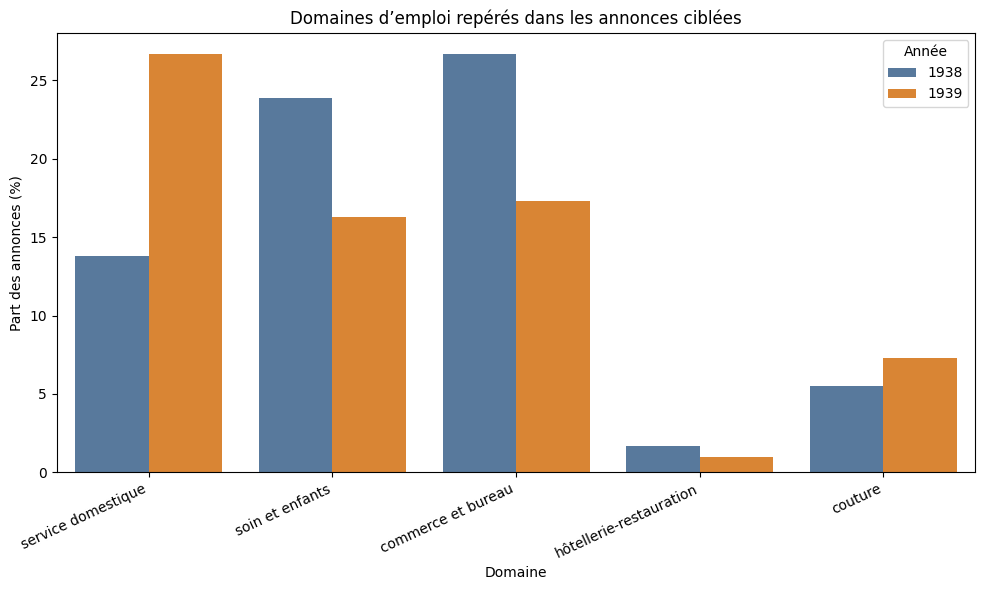

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=domaines_finaux_df,
    x="domaine",
    y="pourcentage",
    hue="ANNÉE",
    palette=["#4C78A8", "#F58518"]
)

plt.title(
    "Domaines d’emploi repérés dans les annonces ciblées"
)
plt.xlabel("Domaine")
plt.ylabel("Part des annonces (%)")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Année")
plt.tight_layout()
plt.show()

## Bilan du TP4

L’analyse porte sur 648 passages publiés en 1938 et 1939 contenant la construction « jeune fille » et ses variantes abrégées. L’extraction YAKE a d’abord montré l’influence de la requête et des formules répétitives des petites annonces. Après nettoyage, le vocabulaire obtenu renvoie surtout aux références, aux qualités déclarées et aux emplois domestiques.

Le classement par domaines montre que le commerce et le bureau sont davantage repérés en 1938, tandis que le service domestique est davantage présent en 1939. Cette comparaison reste partielle : 36,2 % des annonces de 1938 et 42 % de celles de 1939 ne correspondent à aucun des cinq domaines définis. Les erreurs OCR, les abréviations et le chevauchement possible des catégories limitent donc l’interprétation des résultats.